# Análise Exploratória: Desempenho Escolar e Consumo de Álcool
Neste notebook vamos passo a passo explorar os dados dos alunos (arquivo `student-mat.csv`) para entender como diferentes fatores de suas vidas influenciam em sua nota final.

## 1. Importação de Bibliotecas e Leitura de Dados
Vamos importar as bibliotecas e ler nossos dados.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("graficos", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (8, 5)})

df = pd.read_csv("data/student-mat.csv")

display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Traduzindo Todas as Colunas
Vamos renomear todas as colunas do inglês para o português para facilitar a análise e a apresentação.

In [2]:
traducao_colunas = {
    "school":      "escola",
    "sex":         "sexo",
    "age":         "idade",
    "address":     "tipo_residencia",
    "famsize":     "tamanho_familia",
    "Pstatus":     "situacao_pais",
    "Medu":        "educacao_mae",
    "Fedu":        "educacao_pai",
    "Mjob":        "trabalho_mae",
    "Fjob":        "trabalho_pai",
    "reason":      "motivo_escola",
    "guardian":    "responsavel",
    "traveltime":  "tempo_viagem",
    "studytime":   "tempo_estudo",
    "failures":    "reprovacoes_anteriores",
    "schoolsup":   "apoio_escola",
    "famsup":      "apoio_familia",
    "paid":        "aulas_pagas",
    "activities":  "atividades_extracurriculares",
    "nursery":     "frequentou_creche",
    "higher":      "deseja_ensino_superior",
    "internet":    "acesso_internet",
    "romantic":    "relacionamento_romantico",
    "famrel":      "qualidade_relacoes_familiares",
    "freetime":    "tempo_livre",
    "goout":       "sair_com_amigos",
    "Dalc":        "consumo_alcool_semana",
    "Walc":        "consumo_alcool_fds",
    "health":      "saude",
    "absences":    "faltas",
    "G1":          "nota_periodo_1",
    "G2":          "nota_periodo_2",
    "G3":          "nota_final",
}

df = df.rename(columns=traducao_colunas)

display(df.head())

,escola,sexo,idade,tipo_residencia,tamanho_familia,situacao_pais,educacao_mae,educacao_pai,trabalho_mae,trabalho_pai,...,qualidade_relacoes_familiares,tempo_livre,sair_com_amigos,consumo_alcool_semana,consumo_alcool_fds,saude,faltas,nota_periodo_1,nota_periodo_2,nota_final
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2.1 Criando Identificador Único do Aluno
Vamos adicionar uma coluna `id_aluno` como identificador numérico sequencial de cada registro.

In [3]:
df.insert(0, "id_aluno", range(1, len(df) + 1))

display(df[["id_aluno", "escola", "sexo", "idade", "nota_final"]].head())

,id_aluno,escola,sexo,idade,nota_final
0,1,GP,F,18,6
1,2,GP,F,17,6
2,3,GP,F,15,10
3,4,GP,F,15,15
4,5,GP,F,16,10


## 3. Limpeza de Dados
Vamos checar se existem dados nulos (vazios) para tratarmos.

In [4]:
nulos = df.isnull().sum()
print(f"Total de valores nulos no dataset inteiro: {nulos.sum()}")

tamanho_antes = len(df)
df = df[(df["nota_final"] >= 0) & (df["nota_final"] <= 20)]
tamanho_depois = len(df)

if tamanho_antes != tamanho_depois:
    print(f"Foram removidas {tamanho_antes - tamanho_depois} linhas com notas inválidas.")
else:
    print("Todas as notas parecem corretas!")

print(f"\nDataset final: {tamanho_depois} alunos e {len(df.columns)} colunas")

Total de valores nulos no dataset inteiro: 0
Todas as notas parecem corretas!

Dataset final: 395 alunos e 34 colunas


## 4. Salvando o Dataset Limpo
Vamos exportar o dataset já traduzido e limpo para um arquivo CSV.

In [5]:
df.to_csv("data/student-mat-limpo.csv", index=False, encoding="utf-8-sig")
print("Dataset limpo salvo como 'student-mat-limpo.csv'")

Dataset limpo salvo como 'student-mat-limpo.csv'


## 5. Análise Exploratória (Gráficos)

### 5.1 Distribuição das Notas Finais
Quantos alunos tiraram cada nota?

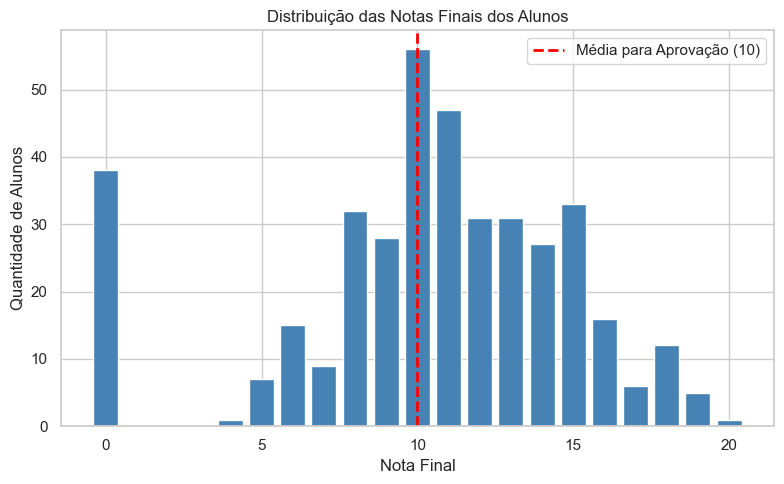

In [6]:
contagem_notas = df["nota_final"].value_counts().sort_index()

plt.figure()
plt.bar(contagem_notas.index, contagem_notas.values, color="steelblue", edgecolor="white")
plt.axvline(10, color="red", linestyle="--", linewidth=2, label="Média para Aprovação (10)")
plt.title("Distribuição das Notas Finais dos Alunos")
plt.xlabel("Nota Final")
plt.ylabel("Quantidade de Alunos")
plt.legend()
plt.tight_layout()
plt.savefig("graficos/distribuicao_notas_finais.png", dpi=150)
plt.show()

Podemos observar que grande parte dos alunos fica próxima da nota 10 (margem de aprovação). Há também um pico em 0, representando alunos que não entregaram trabalhos ou foram reprovados.

### 5.2 Impacto do Tempo de Estudo na Nota Média
Alunos que estudam mais tiram notas melhores?

As categorias de tempo de estudo são:
- 1: menos de 2 horas
- 2: de 2 a 5 horas
- 3: de 5 a 10 horas
- 4: mais de 10 horas

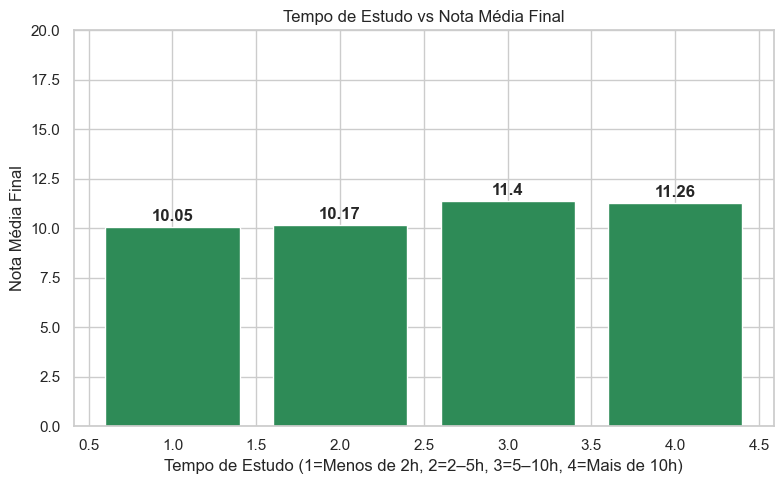

In [7]:
media_por_estudo = df.groupby("tempo_estudo")["nota_final"].mean().round(2)

plt.figure()
plt.bar(media_por_estudo.index, media_por_estudo.values, color="seagreen", edgecolor="white")
plt.title("Tempo de Estudo vs Nota Média Final")
plt.xlabel("Tempo de Estudo (1=Menos de 2h, 2=2–5h, 3=5–10h, 4=Mais de 10h)")
plt.ylabel("Nota Média Final")
plt.ylim(0, 20)

for i, v in zip(media_por_estudo.index, media_por_estudo.values):
    plt.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("graficos/tempo_estudo_vs_nota.png", dpi=150)
plt.show()

Como esperado, quem estuda mais tende a ter uma nota média mais alta. O gráfico mostra uma tendência crescente da categoria 1 para a 3.

### 5.3 Consumo de Álcool no Fim de Semana e a Nota Média
O consumo de álcool no fim de semana afeta o rendimento escolar?

As categorias vão de 1 (muito baixo) a 5 (muito alto).

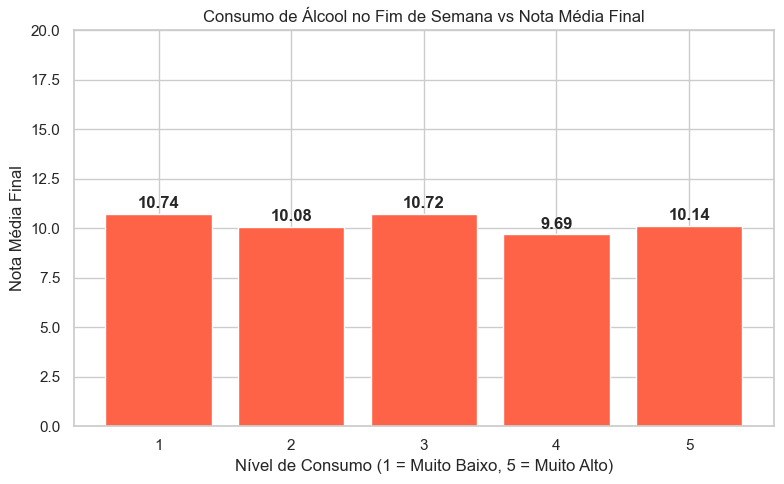

In [ ]:
media_por_alcool = df.groupby("consumo_alcool_fds")["nota_final"].mean().round(2)

plt.figure()
plt.bar(media_por_alcool.index, media_por_alcool.values, color="tomato", edgecolor="white")
plt.title("Consumo de Álcool no Fim de Semana vs Nota Média Final")
plt.xlabel("Nível de Consumo (1 = Muito Baixo, 5 = Muito Alto)")
plt.ylabel("Nota Média Final")
plt.ylim(0, 20)

for i, v in zip(media_por_alcool.index, media_por_alcool.values):
    plt.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("graficos/alcool_fds_vs_nota.png", dpi=150)
plt.show()

Alunos que bebem menos (nível 1) têm notas médias mais altas. Há uma tendência de queda conforme o consumo aumenta.